In [ ]:
import os
import sys

REPO_URL = "https://github.com/gCorona45/Corona_Sechi.git"
REPO_DIR = "/content/Corona_Sechi"

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    # Clonar el repositorio si no está presente
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
        print("Repositorio clonado correctamente.")

    # Navegar a la carpeta del experimento
    os.chdir(os.path.join(REPO_DIR, "Entornos_Complejos"))

    # Añadir src al path
    sys.path.append(os.path.join(REPO_DIR, "Entornos_Complejos", "src"))

    # Instalar dependencias
    !pip install gymnasium flappy-bird-gymnasium gym-simplegrid "gymnasium[other]" numpy pandas matplotlib torch tqdm
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    # Ejecución local: src ya está accesible
    sys.path.append(os.path.join(os.getcwd(), 'src'))

Directorio de trabajo: /content/Corona_Sechi/Entornos_Complejos


In [ ]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import sys
import os
import gym_simplegrid

sys.path.append(os.path.abspath('src'))
from src.utils import *  # type: ignore
from src.tabular_agents import MonteCarloOffPolicyAgent, MonteCarloOnPolicyAgent, SarsaAgent, QLearningAgent
from src.plotting import *

plt.style.use('default') # Configuración de estilo para las gráficas

SEED = 2024
ENV = 'SimpleGrid-8x8-v0'

random.seed(SEED)
np.random.seed(SEED)

### Configuración del experimento

El entorno `SimpleGrid-8x8-v0` presenta una cuadrícula de 64 estados (0–63), con punto de partida en el estado 0 (esquina superior izquierda) y objetivo en el estado 63 (esquina inferior derecha). El agente dispone de 4 acciones: arriba, abajo, izquierda, derecha. Cada episodio tiene un máximo de 100 pasos.

In [ ]:
env = gym.make(ENV, max_episode_steps=100, render_mode="human")
obs, info = env.reset(options={'start_loc':0, 'goal_loc':63}, seed=SEED)

In [ ]:
def run_tabular_experiment(agent_class, env_name, episodes=2000, **kwargs):
    """
    Imparte formación a los agentes de registro
    """
    env = gym.make(env_name)
    env.action_space.seed(SEED)
    agent = agent_class(env, **kwargs)

    stats = {
        'rewards': [],
        'lengths': [],
        'epsilons': []
    }

    eps_end=0.01
    eps_decay=0.995

    print(f"Inicio training: {agent.__class__.__name__} su {env_name}")

    for ep in tqdm(range(episodes)):
        obs, info = env.reset(options={'start_loc':0, 'goal_loc':63}, seed=SEED)
        done = False
        total_reward = 0
        steps = 0

        # Para SARSA: debemos elegir la primera acción ANTES del ciclo
        action = agent.get_action(obs)

        while not done:
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Decidamos cuál será el siguiente paso (necesario para SARSA y para la siguiente fase)
            next_action = agent.get_action(next_obs)

            # LÓGICA DE ACTUALIZACIÓN DIFERENCIADA
            if agent.__class__.__name__ == 'SarsaAgent':
                # SARSA aprende utilizando la acción que realmente llevará a cabo después (On-Policy)
                agent.update(obs, action, next_obs, next_action, reward, terminated, truncated)
            else:
                # Q-Learning y Monte Carlo utilizan la firma estándar
                agent.update(obs, action, next_obs, reward, terminated, truncated, info)


            obs = next_obs
            action = next_action

            total_reward += reward
            steps += 1

        if hasattr(agent, 'end_episode'):
            agent.end_episode()

        # EPSILON DECAY
        if hasattr(agent, 'epsilon'):
            agent.epsilon = max(eps_end, agent.epsilon * eps_decay)

        stats['rewards'].append(total_reward)
        stats['lengths'].append(steps)
        stats['epsilons'].append(getattr(agent, 'epsilon', 0))

    return agent, stats

Todos los agentes se entrenaron con **500 episodios**, `gamma=0.99`, `epsilon=1.0`, `learning_rate=0.1`  inicial con decaimiento multiplicativo (`eps_decay=0.995`, `eps_min=0.01`).

### Resultados del training

Inizio training: QLearningAgent su SimpleGrid-8x8-v0


100%|██████████| 500/500 [00:00<00:00, 844.93it/s]


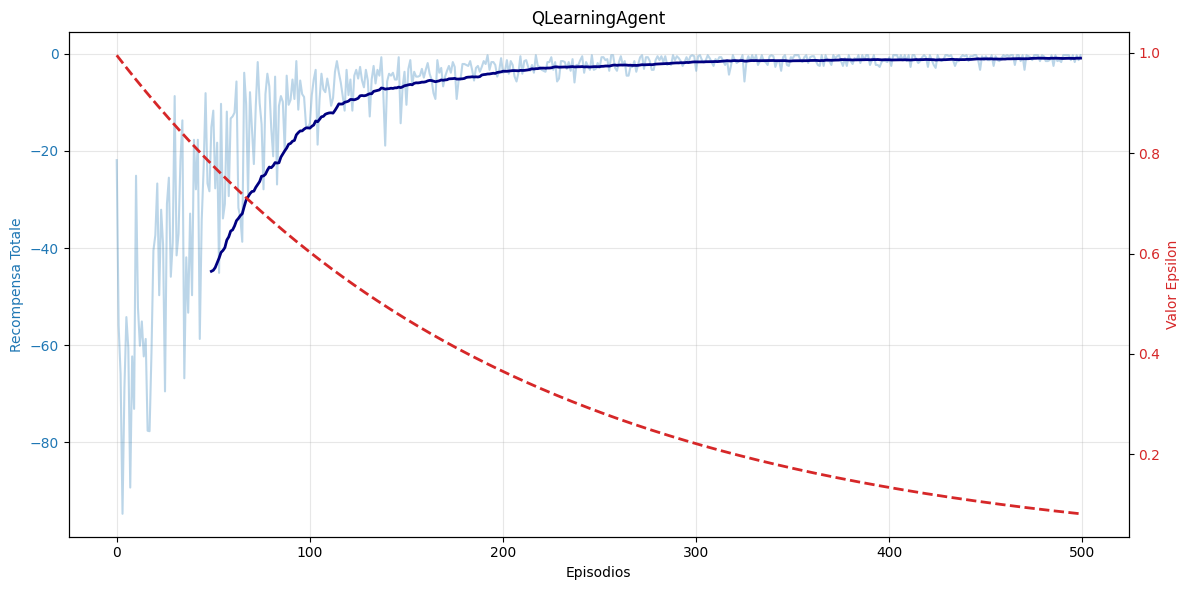

Inizio training: SarsaAgent su SimpleGrid-8x8-v0


100%|██████████| 500/500 [00:00<00:00, 665.95it/s]


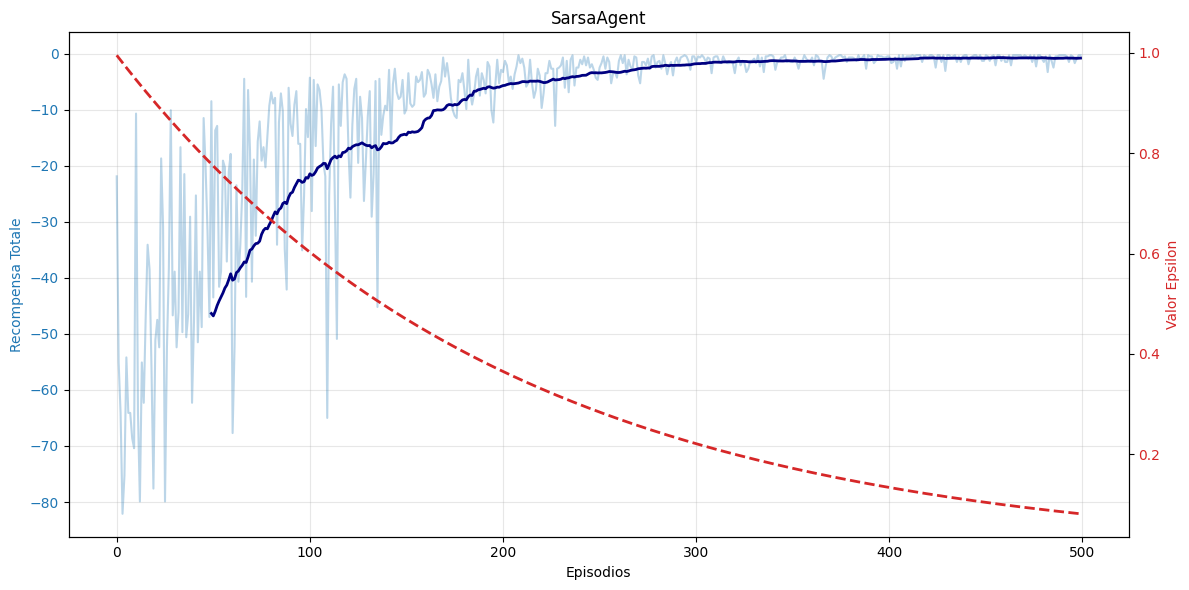

Inizio training: MonteCarloOnPolicyAgent su SimpleGrid-8x8-v0


100%|██████████| 500/500 [00:02<00:00, 182.64it/s]


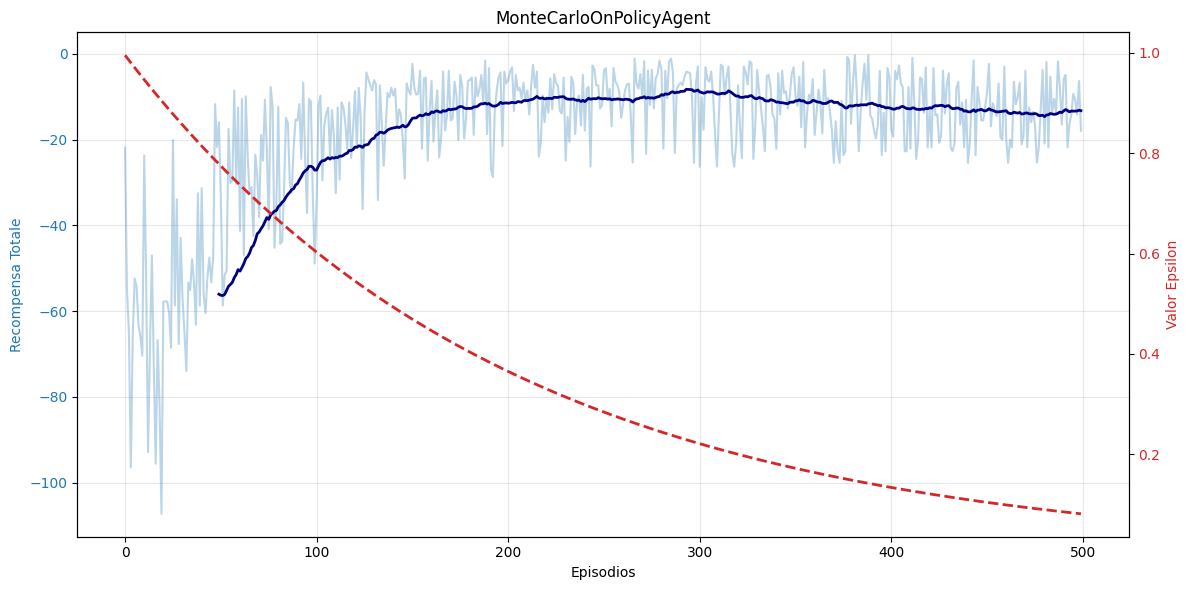

Inizio training: MonteCarloOffPolicyAgent su SimpleGrid-8x8-v0


100%|██████████| 500/500 [00:01<00:00, 347.48it/s]


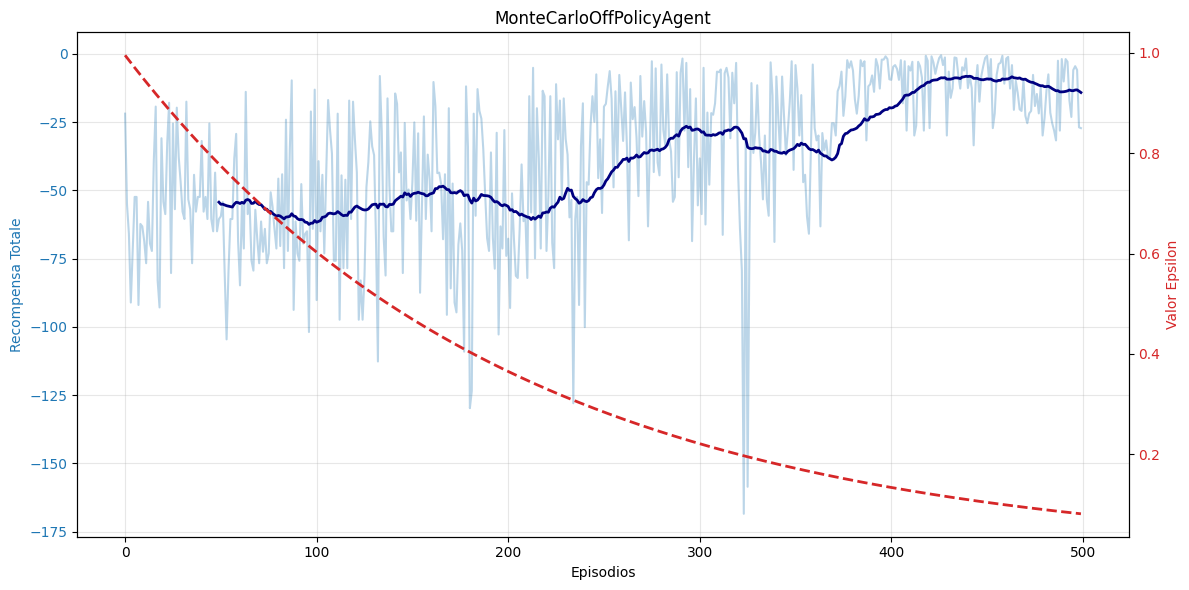

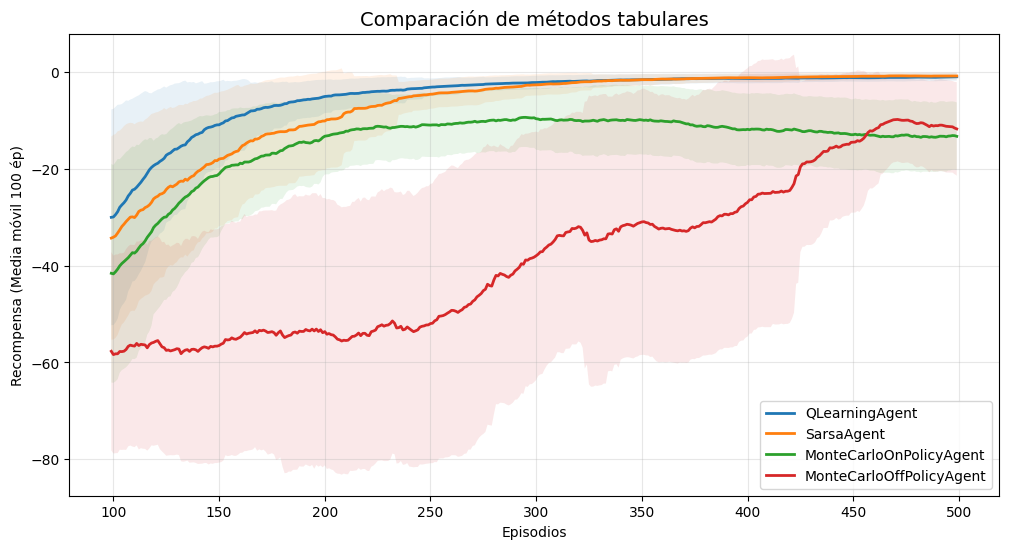


--- REPORT ---


,Algoritmo,Best Reward,Avg last 100,Std Dev
0,QLearningAgent,-0.3,-0.97,0.78
1,SarsaAgent,-0.3,-0.81,0.71
2,MonteCarloOnPolicyAgent,-0.3,-13.27,6.96
3,MonteCarloOffPolicyAgent,-0.5,-11.74,9.61


In [ ]:
# ==========================================================
# REALIZACIÓN DE EXPERIMENTOS
# ==========================================================


EPISODES = 500
common_params = {'gamma': 0.99, 'epsilon': 1}


all_results = {}
all_agents = {}

classes_to_test = [
    (QLearningAgent, {'learning_rate': 0.1}),
    (SarsaAgent, {'learning_rate': 0.1}),
    (MonteCarloOnPolicyAgent, {}),
    (MonteCarloOffPolicyAgent, {})
]

for agent_cls, specific_params in classes_to_test:
    name = agent_cls.__name__
    params = {**common_params, **specific_params}

    agent, stats = run_tabular_experiment(agent_cls, ENV, episodes=EPISODES, **params)

    all_results[name] = stats
    all_agents[name] = agent

    plot_training_results(stats, name)

# ==========================================================
# VISUALIZACIÓN DE RESULTADOS
# ==========================================================
plot_tabular_results(all_results)

print("\n--- REPORT ---")
df_report = analyze_performance_tabular(all_results)
df_report

### Análisis de las tablas Q

Estados conocidos QLearningAgent: 53 su 64
Estados conocidos SarsaAgent: 53 su 64
Estados conocidos MonteCarloOnPolicyAgent: 53 su 64
Estados conocidos MonteCarloOffPolicyAgent: 52 su 64


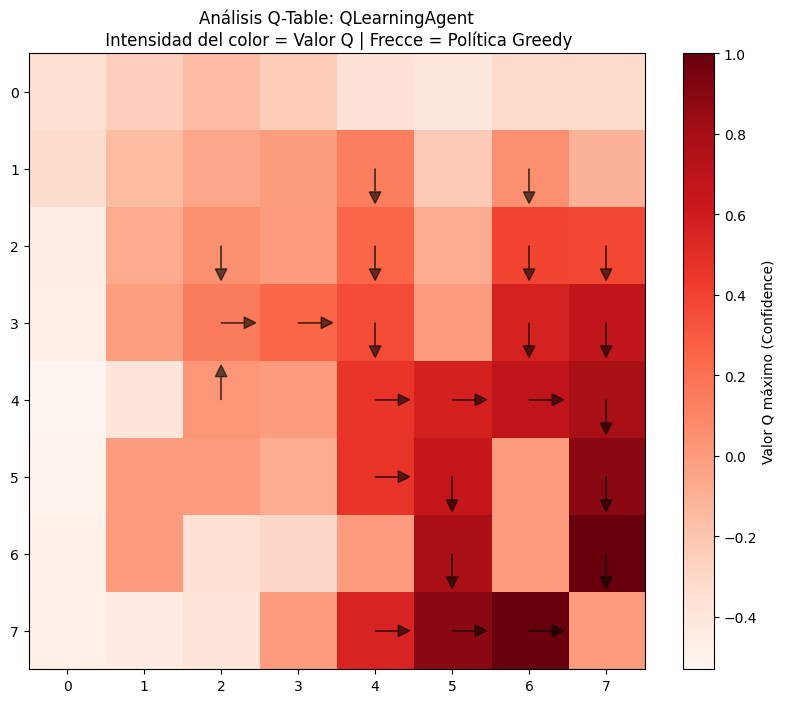

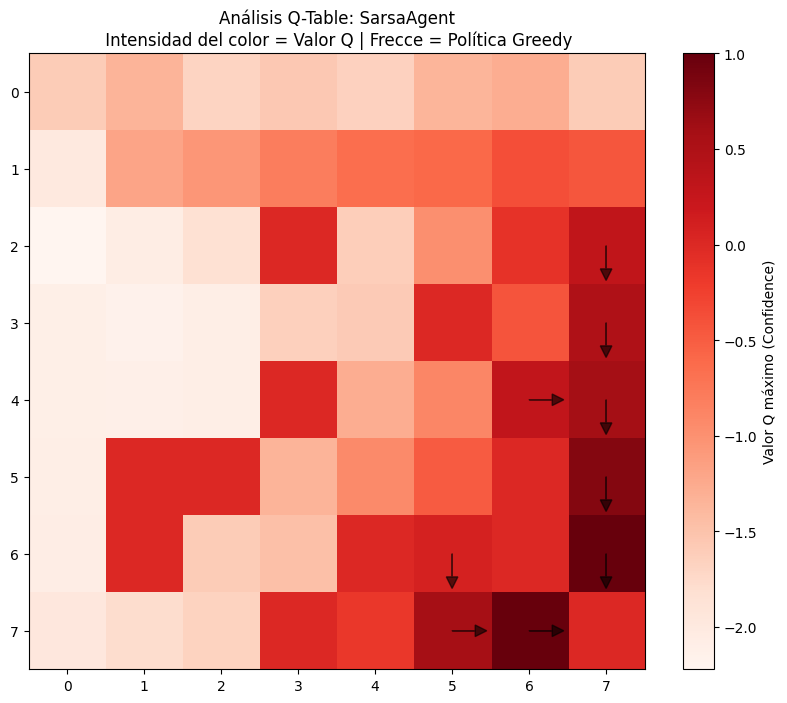

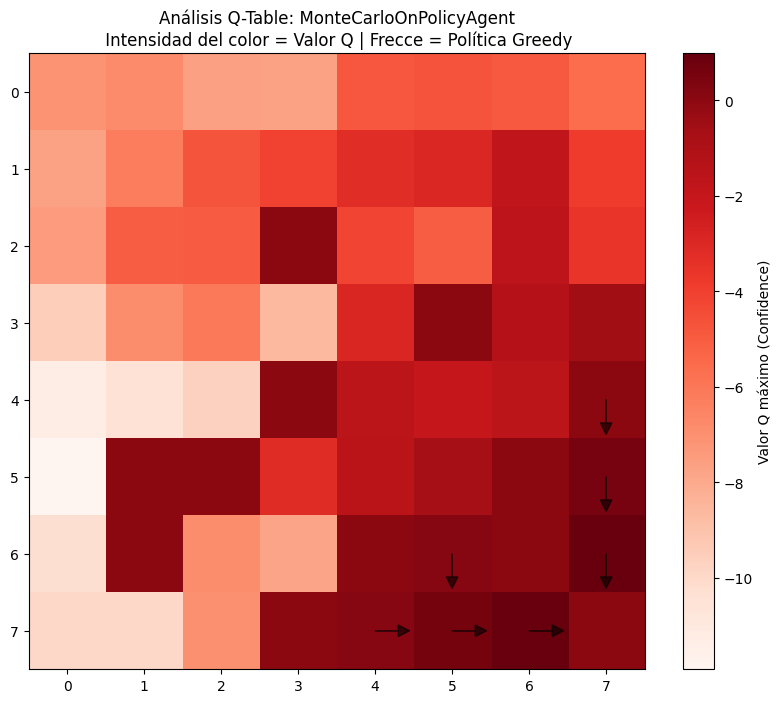

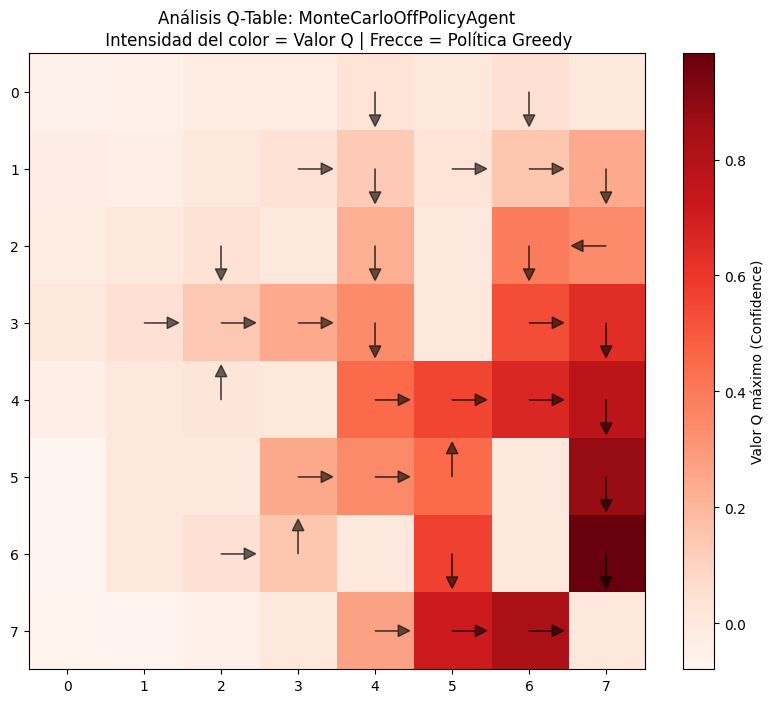

In [ ]:
info_q = analyze_q_table(all_agents['QLearningAgent'])
print(f"Estados conocidos QLearningAgent: {info_q['Estados con conocimiento']} su 64")
print(f"Estados conocidos SarsaAgent: {analyze_q_table(all_agents['SarsaAgent'])['Estados con conocimiento']} su 64")
print(f"Estados conocidos MonteCarloOnPolicyAgent: {analyze_q_table(all_agents['MonteCarloOnPolicyAgent'])['Estados con conocimiento']} su 64")
print(f"Estados conocidos MonteCarloOffPolicyAgent: {analyze_q_table(all_agents['MonteCarloOffPolicyAgent'])['Estados con conocimiento']} su 64")

# Visualización de la política en la cuadrícula
plot_q_values_and_policy(all_agents['QLearningAgent'])
plot_q_values_and_policy(all_agents['SarsaAgent'])
plot_q_values_and_policy(all_agents['MonteCarloOnPolicyAgent'])
plot_q_values_and_policy(all_agents['MonteCarloOffPolicyAgent'])


### Generación de rutas

In [ ]:
all_paths = {}

for a in all_agents.keys():
    traj = get_agent_trajectory(all_agents[a], ENV)
    print(f"Trayectoria para {a}: {traj}")

Trayectoria para QLearningAgent: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4), (4, 5), (4, 6), (4, 7), (5, 7), (6, 7), (7, 7)]
Trayectoria para SarsaAgent: [(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 6), (2, 7), (3, 7), (4, 7), (5, 7), (6, 7), (7, 7)]
Trayectoria para MonteCarloOnPolicyAgent: [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2), (2, 1), (2, 2)]
Trayectoria para MonteCarloOffPolicyAgent: [(0, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (

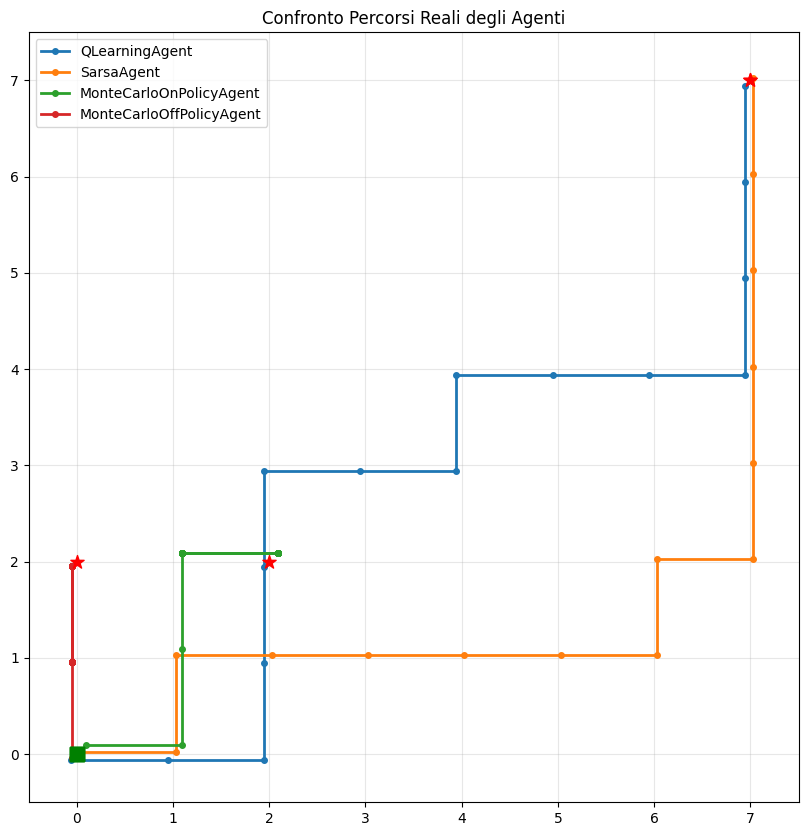

In [ ]:
plot_all_paths(all_agents, ENV)

In [ ]:
analyze_trajectories(all_agents)

,Modelo,Longitud del recorrido,¿Óptimo?
0,QLearningAgent,14,Sì
1,SarsaAgent,14,Sì
2,MonteCarloOnPolicyAgent,64,+50 pasos
3,MonteCarloOffPolicyAgent,64,+50 pasos
